In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [9]:
df = pd.read_csv("fake_bills.csv",delimiter = ";")

In [10]:
df.isnull().sum()

is_genuine       0
diagonal         0
height_left      0
height_right     0
margin_low      37
margin_up        0
length           0
dtype: int64

In [11]:
df.head()

,is_genuine,diagonal,height_left,height_right,margin_low,margin_up,length
0,True,171.81,104.86,104.95,4.52,2.89,112.83
1,True,171.46,103.36,103.66,3.77,2.99,113.09
2,True,172.69,104.48,103.50,4.40,2.94,113.16
3,True,171.36,103.91,103.94,3.62,3.01,113.51
4,True,171.73,104.28,103.46,4.04,3.48,112.54


In [12]:
df.columns

Index(['is_genuine', 'diagonal', 'height_left', 'height_right', 'margin_low',
       'margin_up', 'length'],
      dtype='object')

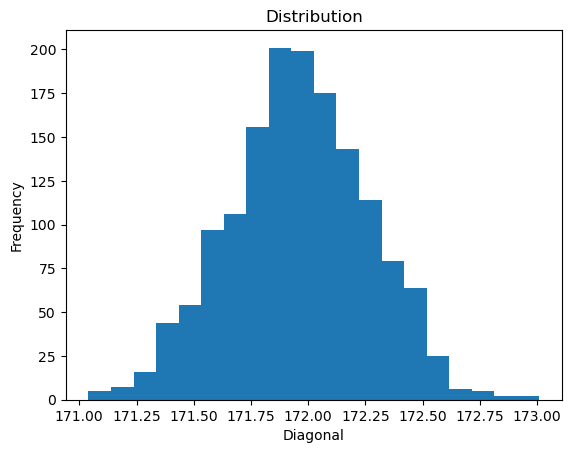

In [13]:
plt.hist(df['diagonal'],bins = 20)
plt.xlabel("Diagonal")
plt.ylabel("Frequency")
plt.title("Distribution")
plt.show()

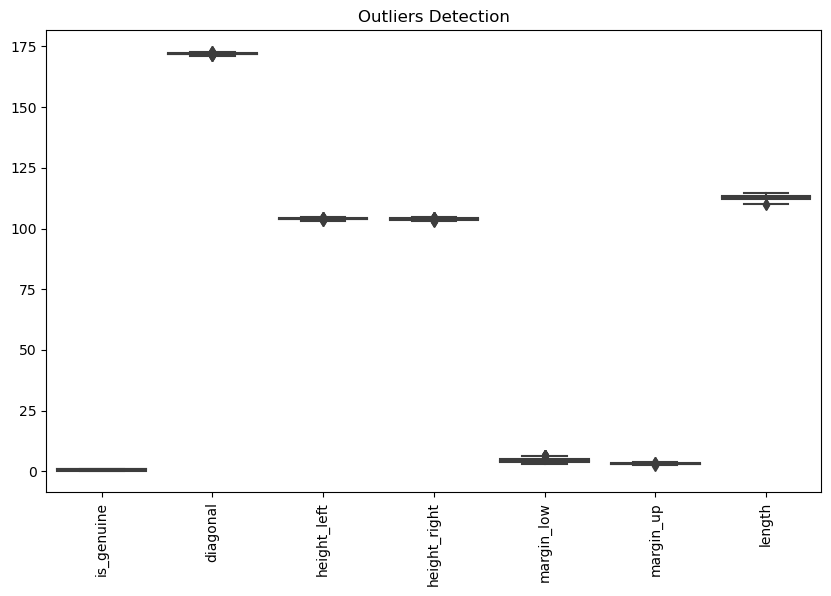

In [14]:
cols_to_convert = df.columns[1:]
df[cols_to_convert] = df[cols_to_convert].apply(pd.to_numeric,errors = 'coerce')
df.fillna(method = 'ffill',inplace = True)

plt.figure(figsize = (10,6))
sns.boxplot(df)
plt.xticks(rotation = 90)
plt.title("Outliers Detection")
plt.show()

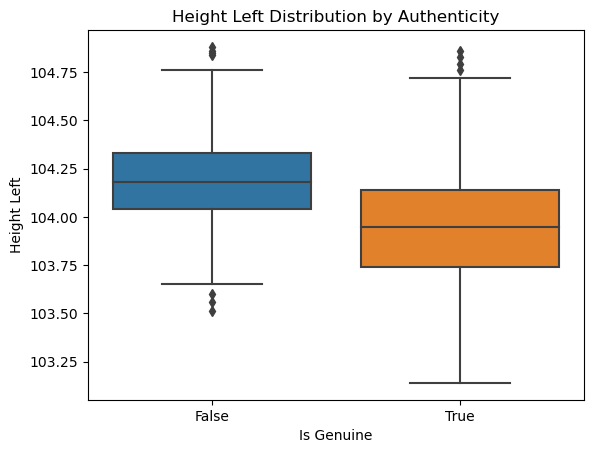

In [15]:
sns.boxplot(x='is_genuine', y='height_left', data=df)
plt.xlabel('Is Genuine')
plt.ylabel('Height Left')
plt.title('Height Left Distribution by Authenticity')
plt.show()

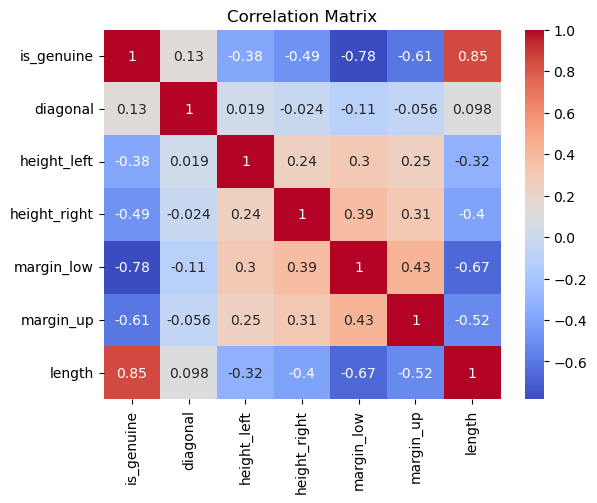

In [16]:
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [17]:
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
from sklearn.impute import KNNImputer
from sklearn.preprocessing import LabelEncoder

In [18]:
imputer = KNNImputer(n_neighbors = 5)
df_imputed = imputer.fit_transform(df)
df = pd.DataFrame(df_imputed,columns = df.columns)

le = LabelEncoder()
df['is_genuine'] = le.fit_transform(df['is_genuine'])

X = df[['diagonal', 'height_left', 'height_right', 'margin_low','margin_up', 'length']]
y = df['is_genuine']

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.25,random_state = 42)
knn = KNeighborsClassifier(n_neighbors = 4)
knn.fit(X_train,y_train)

y_pred = knn.predict(X_test)

accuracy = accuracy_score(y_test,y_pred)
print("Accuracy:",accuracy)
print(classification_report(y_test,y_pred))
cm = confusion_matrix(y_test,y_pred)
print("Confusion Matrix:\n",cm)

results = pd.DataFrame({'Actual':y_test,'Predicted':y_pred})
print(results.head(10))

Accuracy: 0.9946666666666667
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       135
           1       0.99      1.00      1.00       240

    accuracy                           0.99       375
   macro avg       1.00      0.99      0.99       375
weighted avg       0.99      0.99      0.99       375

Confusion Matrix:
 [[133   2]
 [  0 240]]
      Actual  Predicted
1116       0          0
1368       0          0
422        1          1
413        1          1
451        1          1
861        1          1
1063       0          0
741        1          1
1272       0          0
259        1          1


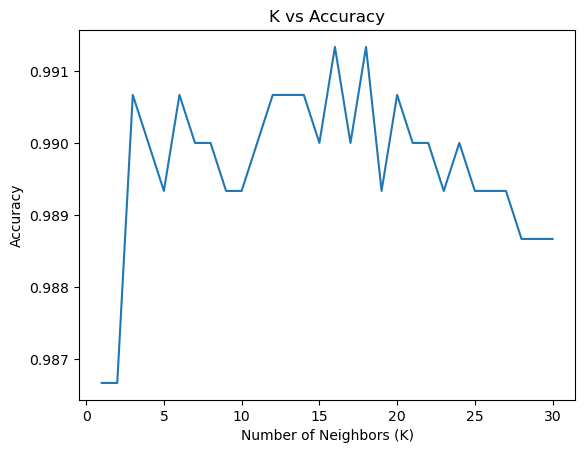

In [30]:
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier

k_values = list(range(1,31))
cv_scores_k = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn,X,y,cv = 5,scoring = 'accuracy')
    cv_scores_k.append(scores.mean())
    
plt.plot(k_values,cv_scores_k)
plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Accuracy")
plt.title("K vs Accuracy")
plt.show()

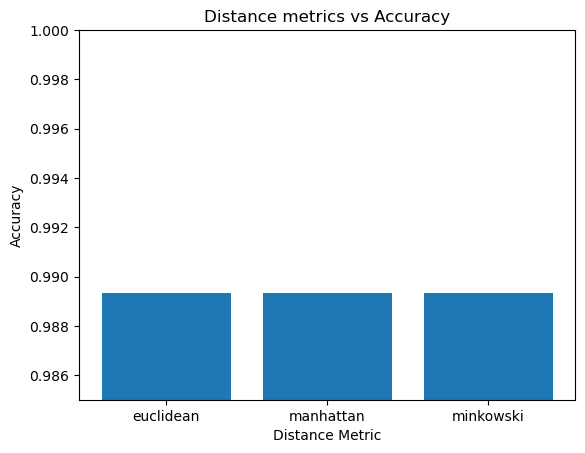

In [25]:
distance_metrics = ['euclidean','manhattan','minkowski']
cv_scores_metrics = []

for metric in distance_metrics:
    knn = KNeighborsClassifier(metric = metric)
    scores = cross_val_score(knn,X,y,cv = 5)
    cv_scores_metrics.append(scores.mean())

plt.bar(distance_metrics,cv_scores_metrics)
plt.xlabel("Distance Metric")
plt.ylabel("Accuracy")
plt.title("Distance metrics vs Accuracy")
plt.ylim(0.985,1.0)
plt.show()

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


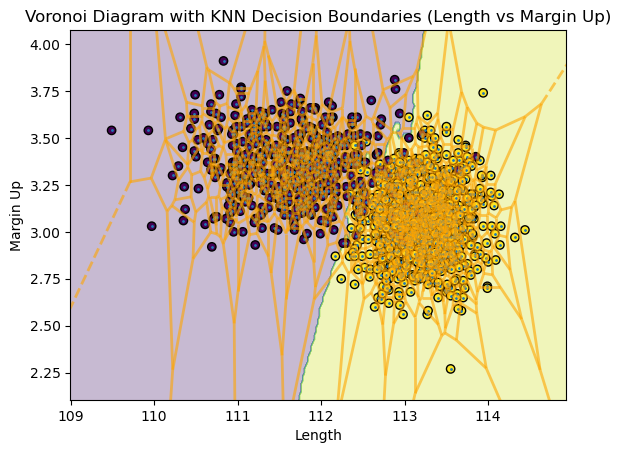

In [26]:
import numpy as np
from scipy.spatial import Voronoi, voronoi_plot_2d

X_viz = X[['length', 'margin_up']]

knn_viz = KNeighborsClassifier(n_neighbors=5) 
knn_viz.fit(X_viz, y)

h = 0.02
x_min, x_max = X_viz['length'].min() - 1, X_viz['length'].max() + 1
y_min, y_max = X_viz['margin_up'].min() - 1, X_viz['margin_up'].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

Z = knn_viz.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

vor = Voronoi(X_viz)
fig = voronoi_plot_2d(vor, show_vertices=False, line_colors='orange', line_width=2, line_alpha=0.6, point_size=2)
plt.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')  # Add decision boundaries
plt.scatter(X_viz['length'], X_viz['margin_up'], c=y, cmap='viridis', edgecolors='k')  # Plot data points
plt.xlabel('Length')
plt.ylabel('Margin Up')
plt.title('Voronoi Diagram with KNN Decision Boundaries (Length vs Margin Up)')
plt.show()

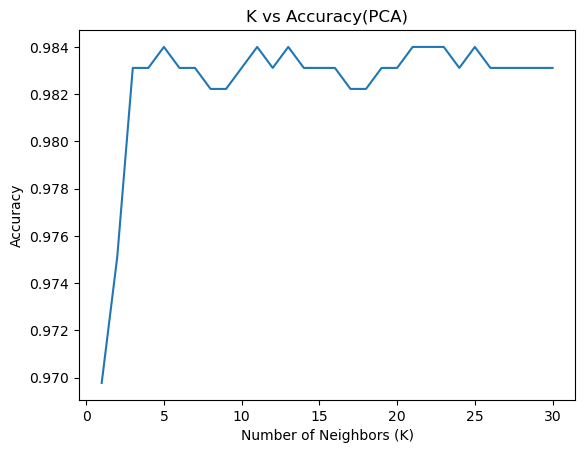

In [29]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components = 3)
X_pca = pca.fit_transform(X_scaled)

X_train,X_test,y_train,y_test = train_test_split(X_pca,y,test_size = 0.25,random_state = 42)

k_values = list(range(1,31))
cv_scores_k = []
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors = k)
    scores = cross_val_score(knn,X_train,y_train,cv = 5,scoring = 'accuracy')
    cv_scores_k.append(scores.mean())

plt.plot(k_values,cv_scores_k)
plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Accuracy")
plt.title("K vs Accuracy(PCA)")
plt.show()

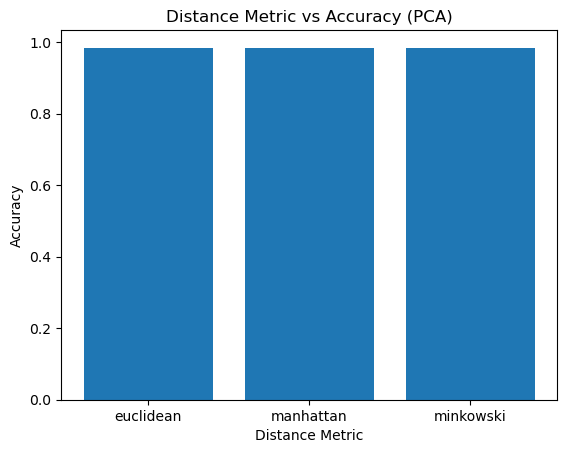

In [32]:
distance_metrics = ['euclidean', 'manhattan', 'minkowski']  
cv_scores_metrics = []

for metric in distance_metrics:
    knn = KNeighborsClassifier(metric=metric)
    scores = cross_val_score(knn, X_train, y_train, cv=5, scoring='accuracy')
    cv_scores_metrics.append(scores.mean())

# Plot distance metric vs accuracy
plt.bar(distance_metrics, cv_scores_metrics)
plt.xlabel('Distance Metric')
plt.ylabel('Accuracy')
plt.title('Distance Metric vs Accuracy (PCA)')
plt.show()

In [33]:
optimal_k = k_values[np.argmax(cv_scores_k)]
optimal_metric = distance_metrics[np.argmax(cv_scores_metrics)]

final_knn = KNeighborsClassifier(n_neighbors=optimal_k, metric=optimal_metric)
final_knn.fit(X_train, y_train)

y_pred = final_knn.predict(X_test)

In [34]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(conf_matrix)

print("Classification Report:")
print(classification_report(y_test, y_pred))

print("Predicted Outputs (first 10):")
print(y_pred[:10])

Accuracy: 0.9893
Confusion Matrix:
[[132   3]
 [  1 239]]
Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.98      0.99       135
           1       0.99      1.00      0.99       240

    accuracy                           0.99       375
   macro avg       0.99      0.99      0.99       375
weighted avg       0.99      0.99      0.99       375

Predicted Outputs (first 10):
[0 0 1 1 1 1 0 1 0 1]
